In [ ]:
# pip install -q "transformers==4.46.3" "sentence-transformers==3.3.1" "huggingface-hub==0.26.5" peft

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 66.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 58.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3

# **IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np
import math
import re
import torch
import gc
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec, FastText
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

2026-06-08 19:44:38.428044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780947878.709609      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780947878.796032      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **SPLIT DATA BUAT AUGMENTASI**

In [3]:
import pandas as pd

df = pd.read_excel("/kaggle/input/data-rs/data-rekap-grading.xlsx", sheet_name="Lembar1")
df

,No,Tanggal Kejadian,Insiden,SKP,Pelanggaran,Kronologis Insiden,Jenis Insiden,Orang Pertama Yang Melaporkan Insiden,Insiden Terjadi Pada,Insiden Menyangkut Pasien,Tempat Insiden\n,Insiden Terjadi pada Pasien,Unit Kerja Penyebab Insiden\n,Akibat Insiden Terhadap Pasien,Tindakan yang dilakukan segera setelah kejadian dan hasilnya\n,Tindakan dilakukan oleh,Apakah kejadian yang sama pernah terjadi di Unit kerja lain,Grading Risiko
0,1,2022-01-13 10:32:42,Medication Eror,Keamanan Obat SKP 3,MDP 1 : Melakukan praktik yang tidak kompeten,08.45 phone dr.Lky melaporkan terkait untuk pa...,KTC - Kejadian Tidak Cedera,Karyawan (Dokter/Perawat/Petugas Lainnya),Pasien,Pasien ICU,ICU,Penyakit Dalam dan Subspesialisasinya,ICU,Tidak ada cedera,"Lapor ke dr.Lky, observasi",Perawat,Ya,HIJAU
1,2,2022-04-22 11:00:53,Medication Eror,Keamanan Obat SKP 3,MDP 14 : Tidak membuat/menyimpan rekam medis d...,Pasien mendapatkan levofloxacin sejak dari IGD...,KTC - Kejadian Tidak Cedera,Karyawan (Dokter/Perawat/Petugas Lainnya),Pasien,Pasien ICU,ICU,Bedah dan Subspesialisasinya,ICU,Tidak ada cedera,Lapor DPJP,Perawat,Ya,HIJAU
2,3,2022-04-22 10:49:41,Medication Eror,Keamanan Obat SKP 3,MDP 14 : Tidak membuat/menyimpan rekam medis d...,Pasien mendapatkan terapi levofloxacin 1x750 m...,KTC - Kejadian Tidak Cedera,Karyawan (Dokter/Perawat/Petugas Lainnya),Pasien,Pasien ICU,ICU,Bedah dan Subspesialisasinya,ICU,Tidak ada cedera,Lapor DPJP,Perawat,Ya,NaN
3,4,2022-04-17 15:54:57,Pasien Jatuh,Pasien Jatuh SKP 6,MDP 4 : Mengabaikan tanggung jawab profesi,Pasien pindahan dari stroke unit. Pindah ke ir...,KTC - Kejadian Tidak Cedera,Karyawan (Dokter/Perawat/Petugas Lainnya),Pasien,Pasien Rawat Inap,RAWAT INAP,Sarafdan Subspesialisasinya,RAWAT INAP,Cedera Ringan,Anamnesa lengkap,Perawat,Ya,NaN
4,5,2022-04-10 11:18:10,Salah rute obat,Keamanan Obat SKP 3,MDP 1 : Melakukan praktik yang tidak kompeten,Pada hari minggu tanggal 10 april 2021 jam 11 ...,KTD - Kejadian Tidak Diharapkan,Pasien,Pasien,Pasien Rawat Inap,RAWAT INAP,Penyakit Dalam dan Subspesialisasinya,RAWAT INAP,Cedera Ringan,"Obs vs dan Ku, dan hasil ttv baik dan gcs somn...",Perawat,Ya,HIJAU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,403,2025-09-09 02:45:20,Ekstubasi,Pencegahan Jatuh SKP 6,MDP 1: Melakukan praktik tidak kompeten,"Pasien terintubasi mode venti Bilevel rate 20,...",KTC,Karyawan (Dokter/Perawat/Petugas Lainya),Pasien,Pasien ICU,ICU,Saraf dan Subspesialisnya,ICU,Tidak ada cidera,Memberikan terapi NRM 15 LPM. Kondisi pasien p...,perawat,Ya,HIJAU
403,404,2025-09-07 14:30:26,Salah menyiapkan dosis obat,Keamanan Obat SKP 3,MDP 1: Melakukan praktik tidak kompeten,"Saat menyiapkan obat sore untuk jam 20.00, pas...",KNC,Karyawan (Dokter/Perawat/Petugas Lainya),Pasien,Pasien ICU,ICU,Anestesi dan Subspesialisasinya,ICU,Tidak ada cidera,Segera konfirmasi ke farmasi dan menyiapkan ob...,Farmasi,Ya,BIRU
404,405,2025-09-03 10:00:35,salah dosis (rate),Keamanan Obat SKP 3,MDP 1: Melakukan praktik tidak kompeten,pasien dengan nicardipin selumnya 4ampul up tu...,KTC,Karyawan (Dokter/Perawat/Petugas Lainya),Pasien,Pasien ICU,ICU,Jantung dan Subspesialisasinya,ICU,Tidak ada cidera,"dilakukan grading oleh PJ unit 5B2, kondisi kl...",perawat,Ya,HIJAU
405,406,2025-09-02 17:00:00,KTD,Identifikasi Pasien SKP 1,MDP 1: Melakukan praktik tidak kompeten,Pasien datang ke MNER dgn keluhan demam sejak ...,KTD,Karyawan (Dokter/Perawat/Petugas Lainya),Pasien,Pasien UGD,RADIOLOGI,Anak dan Subspesialisasinya,RADIOLOGI,Cedera Reversible,melaporkan pada DPJP Pediatri dan DPJP mengkon...,Bidan,Tidak,HIJAU


In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# 1. Muat data ASLI
df_original = pd.read_excel("/kaggle/input/data-rs/data-rekap-grading.xlsx", sheet_name="Lembar1")

# --- DEFINISI KAMUS ---

skp_mapping = {
    '1': 'SKP 1 : Identifikasi Pasien',
    '2': 'SKP 2 : Komunikasi Efektif',
    '3': 'SKP 3 : Keamanan Obat',
    '4': 'SKP 4 : Keselamatan Operasi',
    '5': 'SKP 5 : Pencegahan Infeksi',
    '6': 'SKP 6 : Pencegahan Jatuh',
    '7': 'SKP 6 : Pencegahan Jatuh',
    '8': 'SKP 6 : Pencegahan Jatuh'
}

mdp_mapping = {
    '1' : 'MDP 1 : Melakukan praktik keprofesian tidak kompeten',
    '2' : 'MDP 2 : Tidak merujuk pasien kepada tenaga medis dan tenaga kesehatan yang kompeten',
    '3' : 'MDP 3 : Merujuk pasien kepada tenaga medis dan tenaga kesehatan yang tidak kompeten',
    '4' : 'MDP 4 : Mengabaikan tanggung jawab profesi',
    '5' : 'MDP 5 : Menghentikan kehamilan yang tidak sesuai ketentuan perundang-undangan',
    '6' : 'MDP 6 : Penyalahgunaan kewenangan profesi',
    '7' : 'MDP 7 : Penyalahgunaan alkohol, obat-obatan terlarang, dan zat berbahaya',
    '8' : 'MDP 8 : Penipuan atau tidak memberikan penjelasan yang jujur, etis, dan memadai kepada pasien',
    '9' : 'MDP 9 : Membuka rahasia kesehatan pasien atau tidak menjaga kerahasiaan pasien tanpa pembenaran',
    '10': 'MDP 10 : Melakukan perbuatan tidak patut/tidak pantas/unsur seksual',
    '11': 'MDP 11 : Menolak atau menghentikan tindakan tanpa alasan',
    '12': 'MDP 12 : Pemeriksaan atau pengobatan berlebihan (over-treatment)',
    '13': 'MDP 13 : Meresepkan atau memberikan obat golongan yang tidak ditujukan untuk keperluan perawatan',
    '14': 'MDP 14 : Tidak membuat atau menyimpan rekam medis',
    '15': 'MDP 15 : Membuat keterangan medis yang tidak didasarkan pada hasil pemeriksaan',
    '16': 'MDP 16 : Turut serta melakukan penyiksaan atau perbuatan kejam',
    '17': 'MDP 17 : Mengiklankan diri dan melakukan perang tarif'
}

# Kelas MDP yang di-exclude karena jumlah data terlalu sedikit (n < 5)
# Keputusan: di-exclude agar tidak terjadi label remapping yang menyesatkan
MDP_EXCLUDE = {
    'MDP 2 : Tidak merujuk pasien kepada tenaga medis dan tenaga kesehatan yang kompeten',
    'MDP 9 : Membuka rahasia kesehatan pasien atau tidak menjaga kerahasiaan pasien tanpa pembenaran'
}

# --- FUNGSI CLEANING ---

def clean_skp(text):
    if pd.isna(text) or str(text).strip() in ['-', 'nan', '']:
        return np.nan
    text = str(text).lower()
    match = re.search(r'skp\s*(\d+)', text)
    if match:
        return skp_mapping.get(match.group(1), np.nan)
    return np.nan

def clean_mdp(text):
    if pd.isna(text) or str(text).strip() in ['-', 'nan', '']:
        return np.nan
    text = str(text).lower()
    match = re.search(r'mdp\s*:?\s*(\d+)', text)
    if match:
        return mdp_mapping.get(match.group(1), np.nan)
    if 'mengabaikan tanggung jawab profesi' in text: return mdp_mapping['4']
    if 'praktik' in text and 'tidak kompeten' in text: return mdp_mapping['1']
    if 'tidak membuat' in text and 'rekam medis' in text: return mdp_mapping['14']
    return np.nan

# 2. APPLY CLEANING
print("Sedang melakukan cleaning label...")
df_original['SKP_Clean'] = df_original['SKP'].apply(clean_skp)
df_original['MDP_Clean'] = df_original['Pelanggaran'].apply(clean_mdp)

# 3. HAPUS DATA KOSONG
df_clean = df_original.dropna(subset=['SKP_Clean', 'MDP_Clean']).copy()
print(f"Data setelah hapus NaN : {len(df_clean)} baris")

# 4. EXCLUDE MDP 2 DAN MDP 9
n_before = len(df_clean)
df_clean = df_clean[~df_clean['MDP_Clean'].isin(MDP_EXCLUDE)].copy()
n_excluded = n_before - len(df_clean)
print(f"Excluded {n_excluded} baris (MDP 2 & MDP 9 — data tidak cukup, n < 5)")

# 5. DEFINISIKAN X DAN y (hanya SKP & MDP, Jenis Insiden tidak dimodelkan)
X = df_clean['Kronologis Insiden']
y = df_clean[['SKP_Clean', 'MDP_Clean']].copy()
y.columns = ['SKP', 'MDP Violation']

# 6. SPLITTING DATA — stratify berdasarkan SKP
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y['SKP']
    )
    print("Berhasil melakukan splitting dengan stratify SKP.")
except ValueError as e:
    print(f"Warning: Stratify gagal ({e}). Split random biasa.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

print("-" * 40)
print(f"Total data asli          : {len(df_original)}")
print(f"Total data bersih        : {len(df_clean)}")
print(f"Jumlah data latih (train): {len(X_train)}")
print(f"Jumlah data uji   (test) : {len(X_test)}")
print("-" * 40)
print("\nDistribusi SKP di Test Set:")
print(y_test['SKP'].value_counts())
print("\nDistribusi MDP di Test Set:")
print(y_test['MDP Violation'].value_counts())

# 7. SIMPAN DATA TRAIN DAN TEST
print("\n" + "="*40)
print("MENYIMPAN DATA TRAIN DAN TEST")
print("="*40)

pd.concat([X_train, y_train], axis=1).to_csv('data_train_original.csv', index=False)
print("✅ Data TRAIN berhasil disimpan ke: data_train_original.csv")

pd.concat([X_test, y_test], axis=1).to_csv('data_test_original.csv', index=False)
print("✅ Data TEST berhasil disimpan ke: data_test_original.csv")
print(f"\nKolom Target: {list(y.columns)}")


Sedang melakukan cleaning label...
Data setelah hapus NaN : 393 baris
Excluded 2 baris (MDP 2 & MDP 9 — data tidak cukup, n < 5)
Berhasil melakukan splitting dengan stratify SKP.
----------------------------------------
Total data asli          : 407
Total data bersih        : 391
Jumlah data latih (train): 312
Jumlah data uji   (test) : 79
----------------------------------------

Distribusi SKP di Test Set:
SKP
SKP 3 : Keamanan Obat          54
SKP 6 : Pencegahan Jatuh       17
SKP 1 : Identifikasi Pasien     5
SKP 5 : Pencegahan Infeksi      1
SKP 4 : Keselamatan Operasi     1
SKP 2 : Komunikasi Efektif      1
Name: count, dtype: int64

Distribusi MDP di Test Set:
MDP Violation
MDP 1 : Melakukan praktik keprofesian tidak kompeten    63
MDP 4 : Mengabaikan tanggung jawab profesi              14
MDP 14 : Tidak membuat atau menyimpan rekam medis        2
Name: count, dtype: int64

MENYIMPAN DATA TRAIN DAN TEST
✅ Data TRAIN berhasil disimpan ke: data_train_original.csv
✅ Data TEST berha

# **FUNGSI UNTUK MODELLING**

# **2 Target**

In [5]:
import pandas as pdimport numpy as npimport joblibimport torchimport gcfrom sklearn.preprocessing import LabelEncoderfrom sklearn.pipeline import Pipelinefrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_scorefrom sentence_transformers import SentenceTransformerTRAIN_FILENAME = '/kaggle/input/data-rs/data_train_augmented.csv'TEST_FILENAME  = '/kaggle/input/data-rs/data_test_original.csv'SKP_MODEL_PATH = '/kaggle/input/data-rs/best_model_SKP.pkl'MDP_MODEL_PATH = '/kaggle/input/data-rs/best_model_MDP_Violation.pkl'# Embedding model for classifier-only models (must match training)MDP_EMBEDDING_MODEL = 'indolem/indobert-base-uncased'print(f"Loading Train Data: {TRAIN_FILENAME}")print(f"Loading Test Data : {TEST_FILENAME}")print(f"Loading SKP Model : {SKP_MODEL_PATH}")print(f"Loading MDP Model : {MDP_MODEL_PATH}")try:    df_train = pd.read_csv(TRAIN_FILENAME)    df_test  = pd.read_csv(TEST_FILENAME)    X_train = df_train['Kronologis Insiden'].astype(str).fillna('')    X_test  = df_test['Kronologis Insiden'].astype(str).fillna('')    target_cols = ['SKP', 'MDP Violation']    label_encoders = {}    # IMPORTANT: Fit label encoders on TRAINING data to match model's label space    print("\nEncoding Labels (fitted on training data)...")    for col in target_cols:        le = LabelEncoder()        le.fit(df_train[col].astype(str))        label_encoders[col] = le        print(f"   {col}: {len(le.classes_)} classes")    # Load pre-trained models    skp_model = joblib.load(SKP_MODEL_PATH)    mdp_model = joblib.load(MDP_MODEL_PATH)        skp_is_pipeline = isinstance(skp_model, Pipeline)    mdp_is_pipeline = isinstance(mdp_model, Pipeline)    print(f"\nSKP Model: {type(skp_model).__name__}")    print(f"MDP Model: {type(mdp_model).__name__}")    if skp_is_pipeline:        print(f"  SKP is Pipeline: {list(skp_model.named_steps.keys())}")    else:        print(f"  SKP is classifier-only (expects embeddings)")    if mdp_is_pipeline:        print(f"  MDP is Pipeline: {list(mdp_model.named_steps.keys())}")    else:        print(f"  MDP is classifier-only (expects embeddings)")        print(f"  Using embedding model: {MDP_EMBEDDING_MODEL}")    # Generate predictions    print("\nGenerating predictions...")        # SKP predictions    if skp_is_pipeline:        skp_pred_encoded = skp_model.predict(X_test)    else:        device = 'cuda' if torch.cuda.is_available() else 'cpu'        emb_model = SentenceTransformer(MDP_EMBEDDING_MODEL, device=device)        X_test_emb = emb_model.encode(X_test.tolist(), show_progress_bar=True)        skp_pred_encoded = skp_model.predict(X_test_emb)        del emb_model; gc.collect()        if torch.cuda.is_available(): torch.cuda.empty_cache()    # MDP predictions    if mdp_is_pipeline:        mdp_pred_encoded = mdp_model.predict(X_test)    else:        device = 'cuda' if torch.cuda.is_available() else 'cpu'        emb_model = SentenceTransformer(MDP_EMBEDDING_MODEL, device=device)        X_test_emb = emb_model.encode(X_test.tolist(), show_progress_bar=True)        mdp_pred_encoded = mdp_model.predict(X_test_emb)        del emb_model; gc.collect()        if torch.cuda.is_available(): torch.cuda.empty_cache()    # Encode test labels using training label space    y_test_encoded = pd.DataFrame()    y_test_encoded['SKP'] = label_encoders['SKP'].transform(df_test['SKP'].astype(str))    y_test_encoded['MDP Violation'] = label_encoders['MDP Violation'].transform(df_test['MDP Violation'].astype(str))    # Evaluate models    skp_acc  = accuracy_score(y_test_encoded['SKP'], skp_pred_encoded)    skp_prec = precision_score(y_test_encoded['SKP'], skp_pred_encoded, average='weighted', zero_division=0)    skp_rec  = recall_score(y_test_encoded['SKP'], skp_pred_encoded, average='weighted', zero_division=0)    skp_f1   = f1_score(y_test_encoded['SKP'], skp_pred_encoded, average='weighted', zero_division=0)    mdp_acc  = accuracy_score(y_test_encoded['MDP Violation'], mdp_pred_encoded)    mdp_prec = precision_score(y_test_encoded['MDP Violation'], mdp_pred_encoded, average='weighted', zero_division=0)    mdp_rec  = recall_score(y_test_encoded['MDP Violation'], mdp_pred_encoded, average='weighted', zero_division=0)    mdp_f1   = f1_score(y_test_encoded['MDP Violation'], mdp_pred_encoded, average='weighted', zero_division=0)    # Results dataframe    results = {        'Task': ['SKP', 'MDP Violation', 'Mean'],        'Accuracy': [skp_acc, mdp_acc, (skp_acc + mdp_acc) / 2],        'Precision': [skp_prec, mdp_prec, (skp_prec + mdp_prec) / 2],        'Recall': [skp_rec, mdp_rec, (skp_rec + mdp_rec) / 2],        'F1': [skp_f1, mdp_f1, (skp_f1 + mdp_f1) / 2]    }    df_results = pd.DataFrame(results)    print("\n" + "="*60)    print("MODEL EVALUATION RESULTS")    print("="*60)    display(        df_results.style        .format("{:.2%}", subset=['Accuracy', 'Precision', 'Recall', 'F1'])        .highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1'], color='lightgreen', axis=0)        .set_caption("Evaluation on Held-out Test Set")    )    # Store predictions for later cells    y_pred_encoded = pd.DataFrame({        'SKP': skp_pred_encoded,        'MDP Violation': mdp_pred_encoded    })    print(f"\nData Ready:")    print(f"   Training Set : {len(X_train)} rows")    print(f"   Testing Set  : {len(X_test)} rows")except FileNotFoundError as e:    print(f"Error: File not found. {e}")    raiseexcept Exception as e:    print(f"Error: {e}")    raise

Loading Train Data: /kaggle/input/data-rs/data_train_augmented.csv
Loading Test Data : /kaggle/input/data-rs/data_test_original.csv

Encoding Labels...
   SKP: 6 classes -> ['SKP 1 : Identifikasi Pasien', 'SKP 2 : Komunikasi Efektif', 'SKP 3 : Keamanan Obat', 'SKP 4 : Keselamatan Operasi', 'SKP 5 : Pencegahan Infeksi', 'SKP 6 : Pencegahan Jatuh']
   MDP Violation: 3 classes -> ['MDP 1 : Melakukan praktik keprofesian tidak kompeten', 'MDP 14 : Tidak membuat atau menyimpan rekam medis', 'MDP 4 : Mengabaikan tanggung jawab profesi']
PERINGATAN: MDP Violation — 2 baris test mengandung label tidak dikenal: ['MDP 2 : Tidak merujuk pasien kepada tenaga medis dan tenaga kesehatan yang kompeten', 'MDP 9 : Membuka rahasia kesehatan pasien atau tidak menjaga kerahasiaan pasien tanpa pembenaran']
           Baris ini di-drop dari evaluasi (BUKAN diremap ke kelas lain).

Data Ready:
   Training Set : 628 rows
   Testing Set  : 77 rows

Processing Embedding: Bag of Words...
   RandomForest... OK
   

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   RandomForest... OK
   XGBoost... OK
   LightGBM... OK
   CatBoost... OK

FINAL MODEL RANKING


,Embedding,Classifier,Mean Accuracy,Mean Precision,Mean Recall,Mean F1,Acc (SKP),F1 (SKP),Acc (MDP Violation),F1 (MDP Violation)
0,Bag of Words,LightGBM,92.86%,92.43%,92.86%,92.46%,92.21%,91.03%,93.51%,93.90%
1,Bag of Words,RandomForest,93.51%,90.53%,93.51%,91.93%,90.91%,87.86%,96.10%,96.00%
2,Multilingual-MiniLM,CatBoost,90.91%,90.39%,90.91%,90.23%,87.01%,85.43%,94.81%,95.03%
3,TF-IDF,XGBoost,90.91%,88.91%,90.91%,89.81%,87.01%,84.60%,94.81%,95.03%
4,TF-IDF,CatBoost,89.61%,90.96%,89.61%,89.67%,85.71%,85.45%,93.51%,93.90%
5,Bag of Words,XGBoost,88.96%,89.94%,88.96%,89.02%,83.12%,83.00%,94.81%,95.03%
6,Bag of Words,CatBoost,88.31%,89.97%,88.31%,88.84%,84.42%,84.88%,92.21%,92.80%
7,IndoBERT,CatBoost,89.61%,87.69%,89.61%,88.45%,84.42%,81.88%,94.81%,95.03%
8,TF-IDF,LightGBM,88.96%,88.24%,88.96%,88.38%,85.71%,83.97%,92.21%,92.80%
9,IndoBERT,XGBoost,88.96%,86.43%,88.96%,87.63%,83.12%,80.46%,94.81%,94.81%



Best Model : Bag of Words + LightGBM
Mean F1    : 92.46%
Model saved to: best_model_final.pkl
NOTE: Saved model is a Pipeline (accepts raw text).


TOP 3 MODELS TO ANALYZE:
             Embedding    Classifier   Mean F1
0         Bag of Words      LightGBM  0.924628
1         Bag of Words  RandomForest  0.919335
2  Multilingual-MiniLM      CatBoost  0.902295

PROCESSING Rank 1 Bag of Words LightGBM
Confusion Matrices for BEST MODEL:


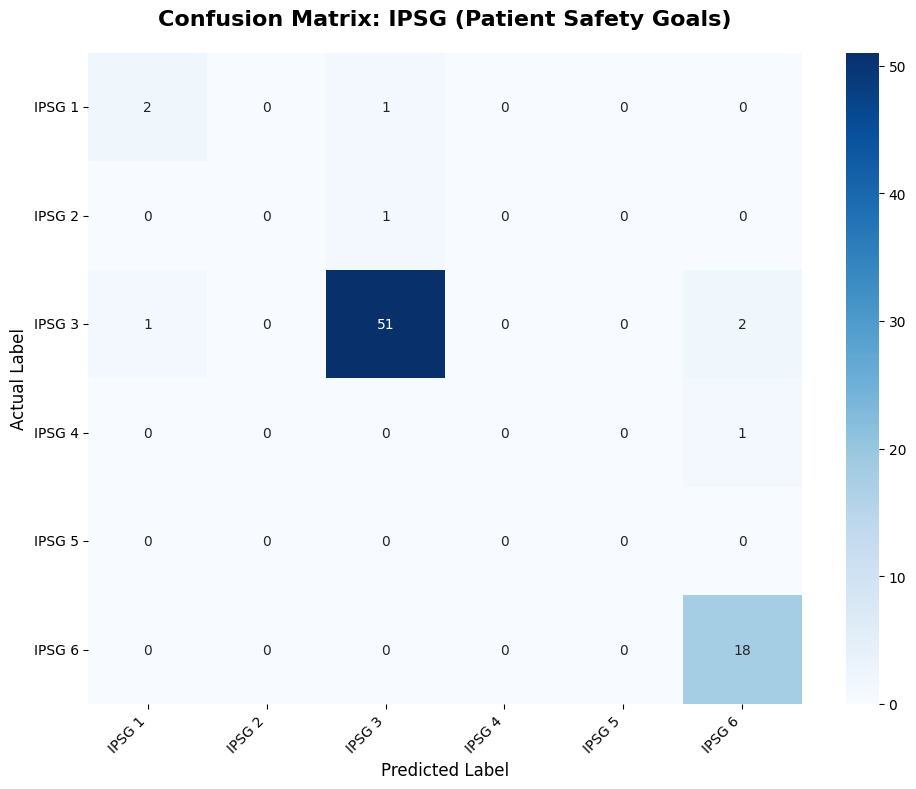

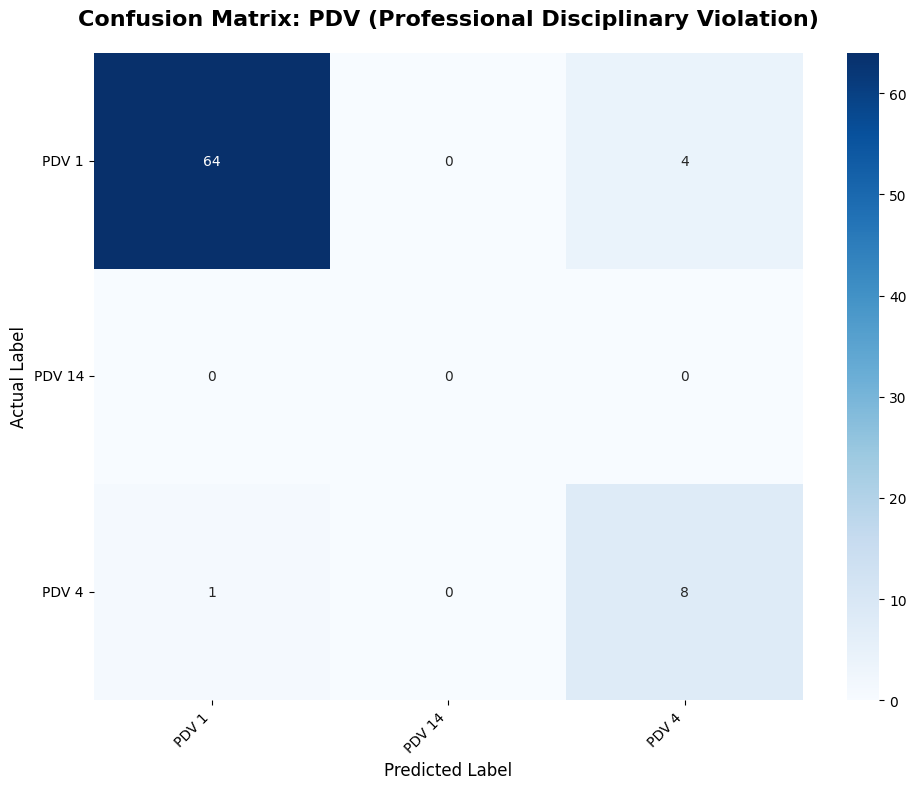

Found 9 errors. Saved to Rank_1_Bag_of_Words_LightGBM_errors.csv

PROCESSING Rank 2 Bag of Words RandomForest
Found 9 errors. Saved to Rank_2_Bag_of_Words_RandomForest_errors.csv

PROCESSING Rank 3 Multilingual-MiniLM CatBoost
Found 13 errors. Saved to Rank_3_Multilingual-MiniLM_CatBoost_errors.csv

Analysis Complete.


In [6]:
import matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.metrics import confusion_matriximport osif 'y_pred_encoded' not in locals():    raise ValueError("y_pred_encoded not found. Run previous modeling cell first.")output_dir = "error_analysis_files"os.makedirs(output_dir, exist_ok=True)def format_label(text, category_type):    text = str(text)    code_part = text.split(" : ")[0]    if category_type == 'SKP':        return code_part.replace("SKP", "IPSG")    elif category_type == 'MDP Violation':        return code_part.replace("MDP", "PDV")    return code_partprint("="*60)print("CONFUSION MATRIX ANALYSIS")print("="*60)for col in target_cols:    le = label_encoders[col]    original_labels  = le.classes_    formatted_labels = [format_label(lbl, col) for lbl in original_labels]        plot_title = ("Confusion Matrix: IPSG (Patient Safety Goals)"                  if col == 'SKP'                  else "Confusion Matrix: PDV (Professional Disciplinary Violation)")        cm = confusion_matrix(y_test_encoded[col], y_pred_encoded[col],                          labels=range(len(original_labels)))        plt.figure(figsize=(10, 8))    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',                xticklabels=formatted_labels, yticklabels=formatted_labels)    plt.title(plot_title, fontsize=16, fontweight='bold', pad=20)    plt.xlabel("Predicted Label", fontsize=12)    plt.ylabel("Actual Label",    fontsize=12)    plt.xticks(rotation=45, ha='right')    plt.yticks(rotation=0)    plt.tight_layout()    plt.show()# Error analysisanalysis_df = pd.DataFrame()analysis_df['Input_Text'] = X_test.reset_index(drop=True)error_mask = pd.Series([False] * len(X_test))for col in target_cols:    le = label_encoders[col]    true_indices = y_test_encoded[col].reset_index(drop=True)    pred_indices = y_pred_encoded[col].astype(int)        analysis_df[f'True_{col}'] = le.inverse_transform(true_indices)    analysis_df[f'Pred_{col}'] = le.inverse_transform(pred_indices)        is_wrong = true_indices != pred_indices    analysis_df[f'Is_Error_{col}'] = is_wrong    error_mask = error_mask | is_wrongdf_errors = analysis_df[error_mask].copy()error_file = os.path.join(output_dir, "model_errors.csv")df_errors.to_csv(error_file, index=False)print(f"\nFound {len(df_errors)} errors. Saved to {error_file}")print("\nError breakdown:")print(f"  SKP errors: {analysis_df['Is_Error_SKP'].sum()}")print(f"  MDP errors: {analysis_df['Is_Error_MDP Violation'].sum()}")print("\nAnalysis Complete.")

# **PATTERN ANALYSIS**
Menghitung Support, Confidence, dan Risk Prediction Accuracy per kelas SKP dan MDP
menggunakan best model dari eksperimen sebelumnya.

In [7]:
import pandas as pdimport numpy as npprint("=" * 70)print("PATTERN ANALYSIS: SUPPORT, CONFIDENCE, RISK PREDICTION ACCURACY")print("=" * 70)if 'y_pred_encoded' not in locals():    raise ValueError("y_pred_encoded not found. Run modeling cell first.")# Decode predictions and ground truth to original labelsle_skp = label_encoders['SKP']le_mdp = label_encoders['MDP Violation']true_skp = le_skp.inverse_transform(y_test_encoded['SKP'].values)pred_skp = le_skp.inverse_transform(y_pred_encoded['SKP'].values.astype(int))true_mdp = le_mdp.inverse_transform(y_test_encoded['MDP Violation'].values)pred_mdp = le_mdp.inverse_transform(y_pred_encoded['MDP Violation'].values.astype(int))n_test = len(true_skp)# PATTERN ANALYSIS PER KELAS SKPprint("\n" + "=" * 70)print("TABEL 1: PATTERN ANALYSIS — KELAS SKP")print("=" * 70)skp_rows = []for skp_class in sorted(le_skp.classes_):    n_class = int(np.sum(true_skp == skp_class))    support = n_class / n_test if n_test > 0 else 0.0    mask_skp = (true_skp == skp_class)    if mask_skp.sum() > 0:        confidence = float(np.sum(true_mdp[mask_skp] == pred_mdp[mask_skp])) / mask_skp.sum()    else:        confidence = 0.0    skp_correct = int(np.sum((true_skp == skp_class) & (pred_skp == skp_class)))    risk_acc = skp_correct / n_class if n_class > 0 else 0.0    short_name = skp_class.split(" : ")[0] if " : " in skp_class else skp_class    skp_rows.append({        'Pattern (SKP Class)': short_name,        'Support (%)': round(support * 100, 2),        'Confidence (%)': round(confidence * 100, 2),        'Risk Prediction Accuracy (%)': round(risk_acc * 100, 2),        'n (test samples)': n_class    })df_skp_pattern = pd.DataFrame(skp_rows)display(df_skp_pattern.style    .format({'Support (%)': '{:.2f}', 'Confidence (%)': '{:.2f}', 'Risk Prediction Accuracy (%)': '{:.2f}'})    .highlight_max(subset=['Support (%)', 'Confidence (%)', 'Risk Prediction Accuracy (%)'], color='lightgreen')    .set_caption("Tabel 1 — Pattern Analysis per Kelas SKP (Patient Safety Goals)"))# PATTERN ANALYSIS PER KELAS MDPprint("\n" + "=" * 70)print("TABEL 2: PATTERN ANALYSIS — KELAS MDP")print("=" * 70)mdp_rows = []for mdp_class in sorted(le_mdp.classes_):    n_class = int(np.sum(true_mdp == mdp_class))    support = n_class / n_test if n_test > 0 else 0.0    mask_mdp = (true_mdp == mdp_class)    if mask_mdp.sum() > 0:        confidence = float(np.sum(true_skp[mask_mdp] == pred_skp[mask_mdp])) / mask_mdp.sum()    else:        confidence = 0.0    mdp_correct = int(np.sum((true_mdp == mdp_class) & (pred_mdp == mdp_class)))    risk_acc = mdp_correct / n_class if n_class > 0 else 0.0    short_name = mdp_class.split(" : ")[0] if " : " in mdp_class else mdp_class    mdp_rows.append({        'Pattern (MDP Class)': short_name,        'Support (%)': round(support * 100, 2),        'Confidence (%)': round(confidence * 100, 2),        'Risk Prediction Accuracy (%)': round(risk_acc * 100, 2),        'n (test samples)': n_class    })df_mdp_pattern = pd.DataFrame(mdp_rows)display(df_mdp_pattern.style    .format({'Support (%)': '{:.2f}', 'Confidence (%)': '{:.2f}', 'Risk Prediction Accuracy (%)': '{:.2f}'})    .highlight_max(subset=['Support (%)', 'Confidence (%)', 'Risk Prediction Accuracy (%)'], color='lightgreen')    .set_caption("Tabel 2 — Pattern Analysis per Kelas MDP (Professional Disciplinary Violation)"))print("\nPattern Analysis complete.")

PATTERN ANALYSIS: SUPPORT, CONFIDENCE, RISK PREDICTION ACCURACY

Menggunakan best model: Bag of Words + LightGBM

TABEL 1: PATTERN ANALYSIS — KELAS SKP


,Pattern (SKP Class),Support (%),Confidence (%),Risk Prediction Accuracy (%),n (test samples)
0,SKP 1,3.90,100.00,66.67,3
1,SKP 2,1.30,100.00,0.00,1
2,SKP 3,70.13,96.30,94.44,54
3,SKP 4,1.30,100.00,0.00,1
4,SKP 5,0.00,0.00,0.00,0
5,SKP 6,23.38,83.33,100.00,18



TABEL 2: PATTERN ANALYSIS — KELAS MDP


,Pattern (MDP Class),Support (%),Confidence (%),Risk Prediction Accuracy (%),n (test samples)
0,MDP 1,88.31,92.65,94.12,68
1,MDP 14,0.00,0.00,0.00,0
2,MDP 4,11.69,88.89,88.89,9



Pattern Analysis selesai.
Best Model: Bag of Words + LightGBM | Mean F1: 92.46%
